# Region boundaries on the ECCO LLC90 lat-lon-cap grid

This example applies `regionate` to the **ECCOv4r4 native lat-lon-cap (LLC90)** grid — a
genuinely *multi-tile* ocean grid whose 13 tiles are connected by an `xgcm`
`face_connections` topology. It demonstrates regionate's topology-aware boundary
tracing: a region's mask boundary is traced tile-by-tile and **stitched across tile
seams**, so a region that spans several tiles yields a single, continuous boundary
loop with a per-corner face index `f_c`.

The grid is loaded by `load_example_ECCO_grid.load_ECCO_LLC90_grid`, which downloads the
geometry from NASA PO.DAAC (via `earthaccess`; needs a free Earthdata Login) the first
time, renames the MITgcm `XC/YC/XG/YG` coordinates to the `geolon*/geolat*` convention,
and uses `sectionate.gridutils.symmetrize` to convert the native MITgcm 'left'-staggered
grid into the symmetric ('outer') grid that regionate/sectionate operate on.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from load_example_ECCO_grid import load_ECCO_LLC90_grid
from regionate import MaskRegions

grid = load_ECCO_LLC90_grid()
grid

<xgcm.Grid>
X Axis (not periodic, boundary='fill'):
  * center   i --> outer
  * outer    i_g_outer --> center
Y Axis (not periodic, boundary='fill'):
  * center   j --> outer
  * outer    j_g_outer --> center

## The LLC90 grid

The grid has 13 tiles (`tile` dimension), tracer-center coordinates `geolon`/`geolat`,
and cell-corner coordinates `geolon_c`/`geolat_c` on the symmetric 'outer' position
(one more point than centers along each axis). `Depth` distinguishes ocean from land.
Below, each tile's ocean depth shows the characteristic lat-lon-cap layout (the Arctic
"cap" is tile 6).

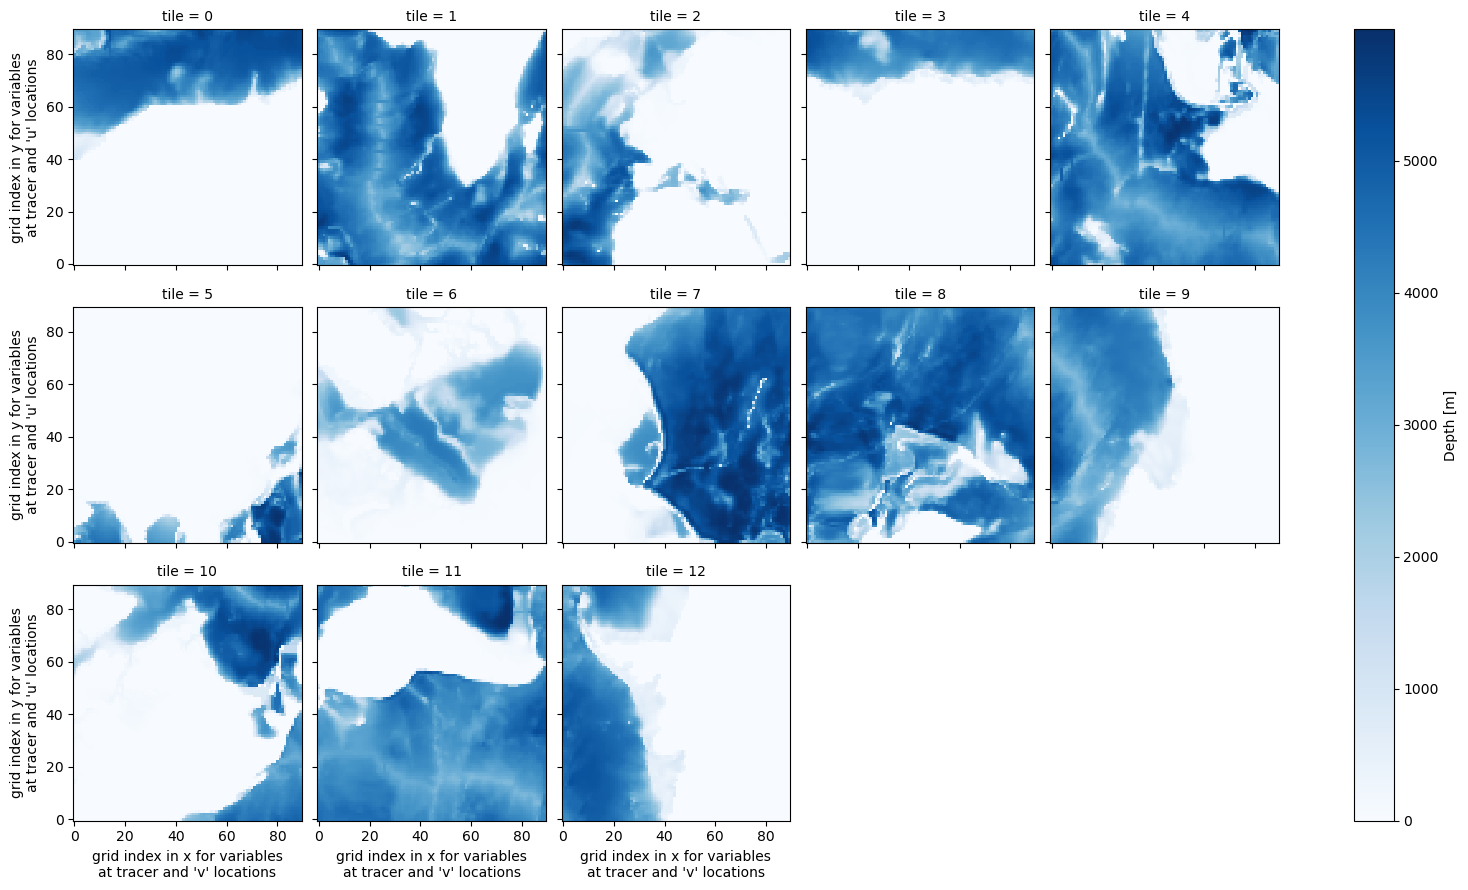

In [2]:
grid._ds["Depth"].plot(col="tile", col_wrap=5, cmap="Blues",
                       cbar_kwargs={"label": "Depth [m]"})
plt.show()

## A region that straddles a tile seam

Tiles 1 and 2 stack in latitude across the seam near 10°N (both cover roughly
38°W–52°E), and `face_connections` joins them. We take a contiguous lat/lon box that
crosses that seam and trace its boundary with `MaskRegions`.

In [3]:
lon = grid._ds["geolon"]
lat = grid._ds["geolat"]

# Contiguous box crossing the tile-1 / tile-2 seam (~10N).
mask = ((lon > -30) & (lon < 20) & (lat > -5) & (lat < 25)).compute()

tiles_in_mask = sorted(set(np.where(mask.values.any(axis=(1, 2)))[0].tolist()))
print(f"masked cells: {int(mask.sum())}  spanning tiles: {tiles_in_mask}")

regions = MaskRegions(mask, grid).region_dict
print(f"number of boundary loops: {len(regions)}")

region = regions[0]
# i_c/j_c/f_c are closed loops (first point repeated at the end); the lon/lat
# corner arrays are open, so drop the closing point to align them.
fc_closed = np.asarray(region.f_c)
faces = fc_closed[:-1]
print(f"loop 0: {len(region.lons_c)} corners, faces = {sorted(set(faces.tolist()))}")
print(f"number of seam crossings (face changes along the boundary): "
      f"{int((fc_closed[:-1] != fc_closed[1:]).sum())}")

masked cells: 2050  spanning tiles: [1, 2]


number of boundary loops: 1
loop 0: 184 corners, faces = [1, 2]
number of seam crossings (face changes along the boundary): 2


The boundary is a **single closed loop** even though the region lives on two different
tiles: regionate dropped the internal tile-seam faces and stitched the surviving
boundary across the seam. The per-corner face index `f_c` switches between tile 1 and
tile 2 where the boundary crosses the seam.

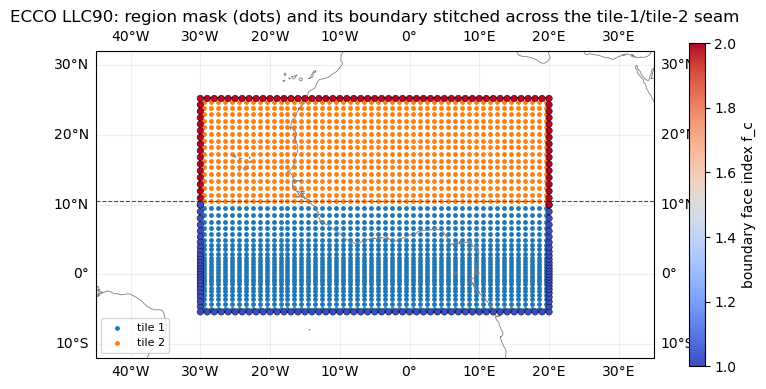

In [4]:
fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-45, 35, -12, 32], crs=ccrs.PlateCarree())
ax.coastlines(color="0.5", linewidth=0.6)
ax.gridlines(draw_labels=True, alpha=0.2)

# Masked cell centers, coloured by tile.
for t in tiles_in_mask:
    m = mask.isel(tile=t).values
    ax.scatter(lon.isel(tile=t).values[m], lat.isel(tile=t).values[m],
               s=6, label=f"tile {t}")

# Traced boundary, with corners coloured by face index f_c.
ax.plot(region.lons_c, region.lats_c, "-", color="k", lw=1.2, zorder=4)
sc = ax.scatter(region.lons_c, region.lats_c, c=faces, cmap="coolwarm",
                s=22, zorder=5, edgecolor="k", linewidth=0.3)
ax.axhline(10.5, color="0.3", ls="--", lw=0.8)  # approx tile-1 / tile-2 seam
plt.colorbar(sc, ax=ax, label="boundary face index f_c", shrink=0.7)
ax.legend(loc="lower left", fontsize=8)
ax.set_title("ECCO LLC90: region mask (dots) and its boundary stitched across the "
             "tile-1/tile-2 seam")
plt.show()

## Notes and current limits

- regionate's multi-tile boundary tracing needs only the grid's corner coordinates and
  its `face_connections` topology (via `xgcm` mask padding), so it works directly on the
  symmetrized ECCO grid.
- The LLC90 **Arctic cap** (tile 6) has rotated/reversed seam connections whose `xgcm`
  halo filling is not yet guaranteed reciprocal; cap-crossing regions are therefore not
  demonstrated here (that neighbour-reciprocity work is upstream). Mid-latitude
  multi-tile regions, like the one above, are fully supported.